# 상태 조건부 모델 결합 비교

KNHANES 2021–2024 / 4,068명 / 19–39세. 실행된 집계 분석 노트북.

**동적 결합의 소폭 개선은 관찰됐지만 강한 LR 대조군에 대한 우월성은 확인되지 않았다.**

네 동시 소견의 다중 라벨 과제이며 임상 진단이나 독립적인16-class 학습이 아니다. 아래 코드는 집계 결과를 다시 표시·계산하고 가중치 학습을 재실행하지 않는다.

## 자료와 검증 경계

5개 outer PSU 분할을 고정하고 meta 학습은 outer-fit 내부3-fold held-out 예측만 사용했다. 전처리도 해당 학습 역할에서만 적합했다. base와 meta의 개발 검증 재사용 및 이전 결과를 본 개발 이력이 있으므로 탐색적 평가다. `clean`에도 자연 결측이 남아 있으며 `missing20`은3개의 합성 누락 view 평균이다.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
DATA = json.loads('{"version": "v15_conditional", "cohort": {"years": {"2021": 1039, "2022": 1013, "2023": 1010, "2024": 1006}, "n": 4068, "age": "19-39", "features": 19, "encoded_features": 72}, "metric": "Each label AP uses survey sample weights; macro AP is the unweighted mean across4 labels. clean retains natural missingness. missing20 averages3 synthetic masked views.", "latest": {"plan": {"data": "Exact v9 five PSU-separated pooled 2021-2024 folds; 4068 participants.", "base_models": "Frozen v13 full-fit and v14 inner-fold models. Reconstruct inner held-out scores with identical 3-fold PSU splits; no base retraining.", "meta_training": "Only original outer-fit participants, each scored by an inner model that excluded their PSU. Clean and one masked view; count unique people for state shrinkage.", "state": "Any observed input missing (excluding age/sex) crossed with per-label expert logit SD above training weighted 75th percentile. No true outcome used to assign state.", "grid": "Per expert set: static mean/logit mean/stack C=.01,.1,1; context stack quality/profile x C=.01,.1; softmax mixture quality/profile x ridge=.01,.1; state stack C=.1 x shrink100,500. Both fullfit/inner_bag validation paths.", "expert_sets": {"three": [0, 1, 2], "assisted": [0, 1, 2, 3], "LR": [3]}, "selection": "Freeze best static, best dynamic, and best overall separately, using original validation .5 clean macro AP + .5 mean of three masked APs. No forced dynamic winner.", "calibration": "Single temperature on original calibration clean+masked after selection.", "evaluation": "Original outer test once per prespecified candidate family; reused previously inspected data, exploratory. Missingness is synthetic requested20%, WC/WHtR linked.", "uncertainty": "200 paired full-frame PSU conditional bootstraps, fixed predictions; no training/selection uncertainty or multiplicity adjustment.", "limitations": "Base hyperparameters and new meta configurations reuse development validation; not fully nested hyperparameter selection. One LR expert has no inter-expert disagreement."}, "models": {"three_static": {"clean": {"macro_ap": 0.37065084735698484, "macro_auc": 0.7796026620290923, "macro_brier": 0.10561915865243114, "micro_ap": 0.3853787519222629, "macro_f1": 0.17692472894001707, "hamming_loss": 0.141686153426083, "subset_accuracy": 0.6125204518241335, "joint_argmax_accuracy": 0.6125204518241335, "joint_nll": 1.3814422925988896, "any_auc": 0.7880466733593433, "count_mae": 0.5468724147851103, "per_label": {"0": {"ap": 0.3728333400200904, "auc": 0.7998917327499449, "brier": 0.09539754770003767}, "1": {"ap": 0.2847322602634956, "auc": 0.7672705666539887, "brier": 0.08170909242245238}, "2": {"ap": 0.4428632746178701, "auc": 0.7957118213235465, "brier": 0.12546694292496008}, "3": {"ap": 0.38217451452648327, "auc": 0.755536527388889, "brier": 0.11990305156227445}}}, "missing20": {"macro_ap": 0.3527268336758452, "macro_auc": 0.7632865487414345, "macro_brier": 0.10771297598247824, "micro_ap": 0.36803181194066287, "macro_f1": 0.12298074340966203, "hamming_loss": 0.14260101288118002, "subset_accuracy": 0.615150792460403, "joint_argmax_accuracy": 0.615150792460403, "joint_nll": 1.4139205785333653, "any_auc": 0.7677177396574043, "count_mae": 0.5757934588548026}}, "three_dynamic": {"clean": {"macro_ap": 0.3709069997031774, "macro_auc": 0.7793807115812385, "macro_brier": 0.10554035033739063, "micro_ap": 0.386427531733994, "macro_f1": 0.16432684624751248, "hamming_loss": 0.14175218328244865, "subset_accuracy": 0.6115159754796282, "joint_argmax_accuracy": 0.6115159754796282, "joint_nll": 1.381101238215061, "any_auc": 0.7886939421592232, "count_mae": 0.5458383086421442, "per_label": {"0": {"ap": 0.37343002851214496, "auc": 0.7994652703922953, "brier": 0.0953205919953524}, "1": {"ap": 0.2813866013063188, "auc": 0.7662953813566736, "brier": 0.08184749992405718}, "2": {"ap": 0.4443991477288113, "auc": 0.7946980932334902, "brier": 0.1253809001029862}, "3": {"ap": 0.3844122212654347, "auc": 0.7570641013424946, "brier": 0.11961240932716678}}}, "missing20": {"macro_ap": 0.3534418177975222, "macro_auc": 0.7644287946296107, "macro_brier": 0.10757272666644829, "micro_ap": 0.36927491943134516, "macro_f1": 0.12550677774815008, "hamming_loss": 0.1423209121199938, "subset_accuracy": 0.6147580995764833, "joint_argmax_accuracy": 0.6147580995764833, "joint_nll": 1.411892403440052, "any_auc": 0.768733840577074, "count_mae": 0.5732436670627344}}, "three_selected": {"clean": {"macro_ap": 0.3697335131578722, "macro_auc": 0.7790361979461229, "macro_brier": 0.10561735335001043, "micro_ap": 0.3854236963126706, "macro_f1": 0.1671908023828173, "hamming_loss": 0.14214660329924256, "subset_accuracy": 0.6106946287866974, "joint_argmax_accuracy": 0.6106946287866974, "joint_nll": 1.3820672770184357, "any_auc": 0.7881261080943213, "count_mae": 0.5467997096683386, "per_label": {"0": {"ap": 0.3719369323064119, "auc": 0.7986114977147267, "brier": 0.09545336544859283}, "1": {"ap": 0.2813848810495753, "auc": 0.7665259745997952, "brier": 0.08179804118728952}, "2": {"ap": 0.4428065222874328, "auc": 0.7948532280607405, "brier": 0.12542717477268073}, "3": {"ap": 0.38280571698806876, "auc": 0.756154091409229, "brier": 0.11979083199147865}}}, "missing20": {"macro_ap": 0.35279679043181805, "macro_auc": 0.7640380243004733, "macro_brier": 0.10763077600686395, "micro_ap": 0.36873825391349846, "macro_f1": 0.12722374152919955, "hamming_loss": 0.14225630224280325, "subset_accuracy": 0.6143459090644988, "joint_argmax_accuracy": 0.6143459090644988, "joint_nll": 1.4126900908405498, "any_auc": 0.7681404485287547, "count_mae": 0.5739154528754807}}, "assisted_static": {"clean": {"macro_ap": 0.37100083901741, "macro_auc": 0.7794096130282171, "macro_brier": 0.10569078564307133, "micro_ap": 0.3850780006213746, "macro_f1": 0.18461998333353027, "hamming_loss": 0.1407684659169841, "subset_accuracy": 0.6121643549648204, "joint_argmax_accuracy": 0.6121643549648204, "joint_nll": 1.3821116466492274, "any_auc": 0.7877909428519655, "count_mae": 0.5472508619793494, "per_label": {"0": {"ap": 0.373700984431458, "auc": 0.799745988751362, "brier": 0.09540491024643998}, "1": {"ap": 0.28677940173005373, "auc": 0.7671497953582049, "brier": 0.08168953106164334}, "2": {"ap": 0.44221743878373204, "auc": 0.7953145916172695, "brier": 0.12568421966846435}, "3": {"ap": 0.3813055311243962, "auc": 0.7554280763860319, "brier": 0.11998448159573757}}}, "missing20": {"macro_ap": 0.35171227476346917, "macro_auc": 0.7630003877737982, "macro_brier": 0.10781121694608627, "micro_ap": 0.36670145865994414, "macro_f1": 0.12761565704840863, "hamming_loss": 0.14233882014422763, "subset_accuracy": 0.6141958822771167, "joint_argmax_accuracy": 0.6141958822771167, "joint_nll": 1.4149000176108322, "any_auc": 0.7672523020855945, "count_mae": 0.5761538720439819}}, "assisted_dynamic": {"clean": {"macro_ap": 0.3722306254598153, "macro_auc": 0.7799351682610667, "macro_brier": 0.10548893115104302, "micro_ap": 0.3869922684466124, "macro_f1": 0.16565565084958891, "hamming_loss": 0.14173614623034592, "subset_accuracy": 0.6111358960931296, "joint_argmax_accuracy": 0.6111358960931296, "joint_nll": 1.3802771547728638, "any_auc": 0.7890644552769048, "count_mae": 0.545533952040508, "per_label": {"0": {"ap": 0.37469478725028826, "auc": 0.8002633904290689, "brier": 0.09527365889899618}, "1": {"ap": 0.28486989398507545, "auc": 0.7665140253721678, "brier": 0.08176548357571624}, "2": {"ap": 0.44450766862974705, "auc": 0.7955420314111112, "brier": 0.12533462029501422}, "3": {"ap": 0.38485015197415035, "auc": 0.757421225831919, "brier": 0.11958196183444549}}}, "missing20": {"macro_ap": 0.3526237509339946, "macro_auc": 0.7638273369060732, "macro_brier": 0.10768107471169397, "micro_ap": 0.36837873437450347, "macro_f1": 0.12815818000200477, "hamming_loss": 0.14266682749830997, "subset_accuracy": 0.6145206489812675, "joint_argmax_accuracy": 0.6145206489812675, "joint_nll": 1.4128965690641813, "any_auc": 0.7687151789899666, "count_mae": 0.5733160148223478}}, "assisted_selected": {"clean": {"macro_ap": 0.3718827566283291, "macro_auc": 0.7796532027437061, "macro_brier": 0.10556252839038865, "micro_ap": 0.38643812910290687, "macro_f1": 0.17385766398577582, "hamming_loss": 0.1413300097126526, "subset_accuracy": 0.6112370464971599, "joint_argmax_accuracy": 0.6112370464971599, "joint_nll": 1.3811811591156267, "any_auc": 0.788228284078774, "count_mae": 0.5463927214286686, "per_label": {"0": {"ap": 0.3741300960726485, "auc": 0.8000947236269565, "brier": 0.09533627626009128}, "1": {"ap": 0.28606050762793206, "auc": 0.7671380981347681, "brier": 0.08166937893920351}, "2": {"ap": 0.444015848711636, "auc": 0.7952853286349507, "brier": 0.1254534690372094}, "3": {"ap": 0.38332457410109977, "auc": 0.756094660578149, "brier": 0.11979098932505045}}}, "missing20": {"macro_ap": 0.3533261716527399, "macro_auc": 0.764255107418538, "macro_brier": 0.10762023015276811, "micro_ap": 0.36890748936371676, "macro_f1": 0.12603901521951144, "hamming_loss": 0.14228702562163667, "subset_accuracy": 0.6142678675316552, "joint_argmax_accuracy": 0.6142678675316552, "joint_nll": 1.4125994762961993, "any_auc": 0.7682278675468771, "count_mae": 0.574407050541097}}, "LR_static": {"clean": {"macro_ap": 0.3733662974913895, "macro_auc": 0.7802714488501052, "macro_brier": 0.10548455628957953, "micro_ap": 0.38754159260604965, "macro_f1": 0.1847435818388531, "hamming_loss": 0.14102928146902557, "subset_accuracy": 0.6141176930026693, "joint_argmax_accuracy": 0.6141176930026693, "joint_nll": 1.3800452626948188, "any_auc": 0.7886067816510415, "count_mae": 0.5459456035056743, "per_label": {"0": {"ap": 0.376392577594581, "auc": 0.7999822543319847, "brier": 0.09527705404492526}, "1": {"ap": 0.2882598967138044, "auc": 0.7670028669265427, "brier": 0.08166698237769872}, "2": {"ap": 0.4455167566094337, "auc": 0.7963661296794382, "brier": 0.1253666602514706}, "3": {"ap": 0.38329595904773894, "auc": 0.7577345444624555, "brier": 0.11962752848422353}}}, "missing20": {"macro_ap": 0.3523909961144382, "macro_auc": 0.7632948758933674, "macro_brier": 0.10775346328811142, "micro_ap": 0.36768303844992967, "macro_f1": 0.1236003411269863, "hamming_loss": 0.14258303295688587, "subset_accuracy": 0.6144416940611884, "joint_argmax_accuracy": 0.6144416940611884, "joint_nll": 1.4145990184590573, "any_auc": 0.7666851972071167, "count_mae": 0.5769890106509616}}, "LR_dynamic": {"clean": {"macro_ap": 0.37277334567735887, "macro_auc": 0.7796490155494773, "macro_brier": 0.10546853127228868, "micro_ap": 0.38706308378257126, "macro_f1": 0.1693639373191055, "hamming_loss": 0.14043423506555106, "subset_accuracy": 0.6143062654040198, "joint_argmax_accuracy": 0.6143062654040198, "joint_nll": 1.3807630293101996, "any_auc": 0.7889050641371104, "count_mae": 0.5467758733147892, "per_label": {"0": {"ap": 0.37751013304600933, "auc": 0.7995630053243765, "brier": 0.09519667854353159}, "1": {"ap": 0.28777100358128255, "auc": 0.7668904733662283, "brier": 0.08164194661089656}, "2": {"ap": 0.44488752538642945, "auc": 0.7963822011263483, "brier": 0.1251233663790721}, "3": {"ap": 0.38092472069571404, "auc": 0.7557603823809562, "brier": 0.1199121335556545}}}, "missing20": {"macro_ap": 0.35330659528714176, "macro_auc": 0.7639033496173848, "macro_brier": 0.10768538382713637, "micro_ap": 0.36862776251715207, "macro_f1": 0.11545453446325767, "hamming_loss": 0.14270666056699546, "subset_accuracy": 0.6152596616755559, "joint_argmax_accuracy": 0.6152596616755559, "joint_nll": 1.413706340095783, "any_auc": 0.767986916646648, "count_mae": 0.5749680642064788}}, "LR_selected": {"clean": {"macro_ap": 0.3734401877998288, "macro_auc": 0.7796474065564882, "macro_brier": 0.10544683552959838, "micro_ap": 0.38764672903167546, "macro_f1": 0.1798201570009404, "hamming_loss": 0.1401406914130765, "subset_accuracy": 0.6146764336678744, "joint_argmax_accuracy": 0.6146764336678744, "joint_nll": 1.3804768187060803, "any_auc": 0.7889012805875659, "count_mae": 0.5462958934939157, "per_label": {"0": {"ap": 0.3775494584666879, "auc": 0.7989074115508212, "brier": 0.09524226930214325}, "1": {"ap": 0.2892380177469611, "auc": 0.7667347646401368, "brier": 0.08157767605860185}, "2": {"ap": 0.4454116150305904, "auc": 0.7968121857747197, "brier": 0.12512850112404617}, "3": {"ap": 0.38156165995507574, "auc": 0.7561352642602752, "brier": 0.11983889563360225}}}, "missing20": {"macro_ap": 0.35300644664355163, "macro_auc": 0.7632996117829941, "macro_brier": 0.10770439864604732, "micro_ap": 0.36880904126587577, "macro_f1": 0.1206618204984277, "hamming_loss": 0.14222821976732927, "subset_accuracy": 0.6148783928853161, "joint_argmax_accuracy": 0.6148783928853161, "joint_nll": 1.4143783931198246, "any_auc": 0.7669728858595621, "count_mae": 0.575756218843463}}}, "selection": [{"selected": {"three_static": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.3832654766447141}, "three_dynamic": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.38557082356131794}, "three_selected": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.38557082356131794}, "assisted_static": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.3826245997006157}, "assisted_dynamic": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3850232347085081}, "assisted_selected": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3850232347085081}, "LR_static": {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3818076239182726}, "LR_dynamic": {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.38728636598782795}, "LR_selected": {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.38728636598782795}}, "candidates": [{"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.37965462251461846}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.37740665125888995}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3794031608072877}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.377396541103874}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.3832654766447141}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.38189403013795553}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3776440378168416}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.37910489840155237}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.3742303476846792}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.37591382074911867}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.38178758294075066}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.381978218012652}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37644748825566965}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3790554148918285}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37838760581630826}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3769941994965105}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.379744514167059}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3776170976430295}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.38328091814330545}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.38557082356131794}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.37113280655080233}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3751645341929825}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.38129026915079534}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3761269429627908}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.38199879480027876}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3791096683607895}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.37894838849807844}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.37655643075952594}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.3818467289146954}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.37840895285462794}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.38151524169718054}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.3764370029021029}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3813510872367894}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.3768550750980745}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.3826245997006157}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.381664840735826}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3793089396578375}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.37913218309172647}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.37430338663776674}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.37701934614845617}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.38092473849858777}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3816208829599137}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3743492290004316}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.37633864691716223}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.38031249382891763}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.37711418520560636}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3813074372328705}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3771101010314073}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.38272441348230435}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3850232347085081}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.36903824067932567}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3738307837731162}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3813395262724877}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3762757845116692}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.38063505532835284}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.37813919374308147}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.38209379055203185}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.3803504901622773}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.3828585156299477}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.3803884755085719}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3777432281981791}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.376532847727173}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3777432281981791}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.376532847727173}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.37925579021764055}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.377715307237823}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3818076239182726}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.37903948574916213}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.3814488091892603}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.37875822914479085}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3793177581267513}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3773814382186782}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37783570633999064}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3760913202543472}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3781503371414243}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3775557511502191}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37784258937164517}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3771045600164036}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.38509736997189786}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.38728636598782795}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3807996139265191}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.38213332370996683}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.37869856959255943}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3783515344764214}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.37951160343138357}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.37882306318151493}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.38272550658865656}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.3777585695542862}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.38153033226955707}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.37801656497315206}]}, {"selected": {"three_static": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.3751085955235691}, "three_dynamic": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.37699458529301844}, "three_selected": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.37699458529301844}, "assisted_static": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.375332723653816}, "assisted_dynamic": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3752025458489962}, "assisted_selected": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.375332723653816}, "LR_static": {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.3690803226144328}, "LR_dynamic": {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37097101455357717}, "LR_selected": {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37097101455357717}}, "candidates": [{"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3459331939522421}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.34039685428275607}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.34548821195821433}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.34048427190009534}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.3751085955235691}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.3690344588418836}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3745860283417878}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.36743659528927797}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.37215258139938456}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.3629316042145019}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.376124426909342}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3717977248818586}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3761414986290538}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.36575046813288115}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.34296879314362283}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3385219414564229}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3450977935105211}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.340139134979003}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.36765367395641063}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.36028302529308254}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.35639518258762704}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3553707390436892}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3417325391681989}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3385988846100262}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.34806216712573}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.34003242234426967}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.3742175023712937}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.3670807981436901}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.37699458529301844}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.36536100802056765}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.34143617020344075}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.33977757314324014}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.34105109178960036}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.33998476803098143}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.37499834610739646}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.3682054083200752}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.375332723653816}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.3673393005813901}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.3731773223558452}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.3639931691939873}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3734427010457778}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.37237626656850964}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3752025458489962}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.36670407109192016}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3414243080718544}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3383061155653828}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3420031255051461}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.33951936775447844}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3658361241276284}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.36040346392780787}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3542594460848889}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.35460355597033166}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3409151790628818}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3382681543398992}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.34508743297497746}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3388859767010661}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.37089638184651397}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.36495811463571826}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.3744401387781104}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.3638118353634463}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.33486128819660615}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.33500839772107605}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.33486128819660615}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.33500839772107605}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.3633940882002628}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.36311333813386576}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.368297186030598}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.3682289858442913}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.3690803226144328}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.36833119072270665}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3637617980674255}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3677140400685855}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37097101455357717}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3672303115393214}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3350659263215916}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3346825769086046}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.33502790688066225}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3345887355039482}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.360258152984557}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3579976720314063}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3573978955786892}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.35678807431914183}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3354126317970465}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3362246530182771}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3383813412063079}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3374584736434225}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.3682825512011192}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.3691453225470267}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.3673154025991092}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.36810377357368795}]}, {"selected": {"three_static": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.495391439627434}, "three_dynamic": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.5004390598430805}, "three_selected": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.5004390598430805}, "assisted_static": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.49576079594367856}, "assisted_dynamic": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.5004471712596041}, "assisted_selected": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.5004471712596041}, "LR_static": {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.4971579102804808}, "LR_dynamic": {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.5012534177334079}, "LR_selected": {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.5012534177334079}}, "candidates": [{"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.4869350419430801}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4893405519181908}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.48699131809801177}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.48942241363904226}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.4950021732430304}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.4951557752989586}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.49416940202855475}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.495391439627434}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.49165419929103993}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.4943875440537866}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.5004390598430805}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.499662223673193}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.49511109189309094}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4947397536032079}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.48934746317911226}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4896680144957546}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.4881879135832783}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.48913405611649674}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.49669906542554654}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4970678122275034}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.48247017765968114}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.48705617657367617}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4879876108593175}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.48640731341728893}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.48957911874541316}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4883309750366528}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.49211668056169144}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.4881756792380759}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.49240760468078204}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.4916938574063907}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.4882466165125656}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.48973550249524767}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.488239680023963}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4894785867355731}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.49432549920303126}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.49576079594367856}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.4939612429828212}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.49267201204264455}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.4919645575163246}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.49405070636152515}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.5000426766654056}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.5004471712596041}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.49356519082857186}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4941838340494649}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.48924395752443595}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4890675897147565}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.4886287450416239}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4892576046820567}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.49531453154183214}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.49698484155135114}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4813104871144037}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4839737782872633}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4879185856590131}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.48615557713965263}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4904900489931986}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.486029913949061}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.4929917934070177}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.4904157526997187}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.4929218103395451}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.4910282390910921}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.48863240904380534}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.48825767496353567}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.48863240904380534}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.48825767496353567}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.4971579102804808}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.49576941423836807}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.4929745249249783}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.49049002875450554}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.49275361006796603}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.4893444999554171}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.5003775799641259}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.5012534177334079}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.4935803514367382}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.49634993975504715}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.488863135463947}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.48885991164468856}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.4886349416679393}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4882825103855999}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.5012205137554122}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.500043650488634}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4893553927870261}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.489953437138292}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.48561399417373663}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.48487996015842916}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4874302415553511}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4863778289840607}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.49525071675623966}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.4927466937744355}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.49507890437846325}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.49236133673620563}]}, {"selected": {"three_static": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3901845778564263}, "three_dynamic": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.38971111016242066}, "three_selected": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3901845778564263}, "assisted_static": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3895587339293445}, "assisted_dynamic": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3893297561105691}, "assisted_selected": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3895587339293445}, "LR_static": {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3847372188461829}, "LR_dynamic": {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3834119436363158}, "LR_selected": {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3847372188461829}}, "candidates": [{"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3790153802255314}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.37650822419755514}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3793160801111718}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.3765393027378058}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.38749655766832153}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.3825674065734591}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3901845778564263}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.3826286414947554}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.38874263666885656}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.3804892408627555}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.38971111016242066}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3859313212967478}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3840092831843022}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3823175865196162}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3783611288522565}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3749572056582381}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37954017674150364}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.37575213663613566}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.378413069816255}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.37386891063622785}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3750938536581908}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3733618617668527}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3815580534645753}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3783774196102708}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.38004867714849955}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3774119064194282}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.38254496711967934}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.37917870727280645}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.3828477390994527}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.37979819079698174}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3789291218036431}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.3755532302153482}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3792778740529037}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.37550901195472564}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.38781567238051445}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.3828030799046894}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3895587339293445}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.3826721081450606}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.38941810720545067}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.380991272288153}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3893297561105691}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.38562184687531137}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.38331740330044817}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.38272486699024516}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3783161485322444}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3746886834866089}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37881496899309974}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3759026152380093}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.37638287274598714}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.37175282300677404}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3740052519988032}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.37272804609375365}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.38135261874576587}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3783234823401683}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3796569487692054}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3776711920387823}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.3839632891435081}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.37672361686283773}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.3857065793087875}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.37865493291841634}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3753019331246219}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.3739328483473967}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.3753019331246219}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.3739328483473967}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.38133716437624277}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.3796215247454299}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3847372188461829}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.3792307391464725}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.38150346185491024}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.3790730436558535}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3831964328380399}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3815693409560466}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37963850536970545}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3834119436363158}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.374872541335785}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.3747784883731047}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.37547636303827714}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.37397590355205934}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.37350087082350825}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.37274401390915646}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.37675099850477234}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.3765171246106856}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.37968091298996476}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.38104520674885833}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.37656152347624017}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.37852119917453175}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.38247752477622227}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.37952636844211074}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.3826908556834403}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.38035436562217007}]}, {"selected": {"three_static": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4085725609130104}, "three_dynamic": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4087072352971367}, "three_selected": {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4087072352971367}, "assisted_static": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4083591545358441}, "assisted_dynamic": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4087473005831494}, "assisted_selected": {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4087473005831494}, "LR_static": {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4082830783101829}, "LR_dynamic": {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4080016685068418}, "LR_selected": {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4082830783101829}}, "candidates": [{"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.4057028204243117}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4085725609130104}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.40570483199413954}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4085630867313459}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.39800926231710454}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.39751376112816117}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3974088561154946}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.39673525866029136}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.3982499613066073}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.3963732324176037}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.40001681427273095}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.40139922150149887}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.40043466211699275}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.40141775410035513}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.4057624764656982}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4082763480412054}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.40584529821030724}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4087072352971367}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4041440118377132}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.40583893246845526}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3957665832966373}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.39757899740839164}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4020502538090206}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4020230863035229}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4058945110870743}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.40806929761526334}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.3856894483470784}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.39540563028885745}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.3907204290434567}, {"spec": {"group": "three", "columns": [0, 1, 2], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.3967037329823053}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.4057921625830241}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4083591545358441}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.40576756697626254}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4082640794894643}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.3967260439016761}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.39797076794314457}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.3973835177382786}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.3967626289961488}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.3979661422338729}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.3957638232637992}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.40132115688411363}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.40232219331939034}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.3998683032393151}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4019049890426615}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.4057405356927374}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4081857412038229}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.40591653576666653}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4087473005831494}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.4038545713399509}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4056206486498287}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3954969587301126}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.39744087750951207}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.40291698954178295}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4019771523375504}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.40549531354260887}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4085297020735358}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.38805287221824053}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.39861698607971574}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.39155044466107314}, {"spec": {"group": "assisted", "columns": [0, 1, 2, 3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.4000088395153327}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.4054280990401816}, {"spec": {"group": "LR", "columns": [3], "kind": "mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4082830783101829}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "fullfit", "validation_score": 0.4054280990401816}, {"spec": {"group": "LR", "columns": [3], "kind": "logit_mean", "dynamic": false, "kwargs": {}}, "base_path": "inner_bag", "validation_score": 0.4082830783101829}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "fullfit", "validation_score": 0.39402883988602533}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.01}}, "base_path": "inner_bag", "validation_score": 0.3932647209796968}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "fullfit", "validation_score": 0.39814582380621144}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 0.1}}, "base_path": "inner_bag", "validation_score": 0.39720576029908555}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "fullfit", "validation_score": 0.3974480195817315}, {"spec": {"group": "LR", "columns": [3], "kind": "stack", "dynamic": false, "kwargs": {"C": 1.0}}, "base_path": "inner_bag", "validation_score": 0.3968388249070588}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.39638793130340544}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.39645704973213136}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.40069208974829684}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4018525366047705}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.4050286979696619}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4077328959089418}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "fullfit", "validation_score": 0.4054156523122661}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "quality"}}, "base_path": "inner_bag", "validation_score": 0.4080016685068418}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.40364225449706226}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.40442244027719865}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.3987492688545775}, {"spec": {"group": "LR", "columns": [3], "kind": "context_stack", "dynamic": true, "kwargs": {"C": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.39991581569162393}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.40268157241944624}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.01, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.4013633604976017}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "fullfit", "validation_score": 0.40530413270707094}, {"spec": {"group": "LR", "columns": [3], "kind": "context_mixture", "dynamic": true, "kwargs": {"regularization": 0.1, "mode": "profile"}}, "base_path": "inner_bag", "validation_score": 0.407987182941711}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "fullfit", "validation_score": 0.39857282264231114}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 100}}, "base_path": "inner_bag", "validation_score": 0.3979899312306542}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "fullfit", "validation_score": 0.39823978952666406}, {"spec": {"group": "LR", "columns": [3], "kind": "state_stack", "dynamic": true, "kwargs": {"C": 0.1, "shrink_people": 500}}, "base_path": "inner_bag", "validation_score": 0.39830694875534667}]}], "audit": [{"fold": 1, "outer_PSU_overlap": 0, "meta_people": 2664, "meta_views": 2, "meta_OOF_coverage": 1, "states": {}}, {"fold": 2, "outer_PSU_overlap": 0, "meta_people": 2607, "meta_views": 2, "meta_OOF_coverage": 1, "states": {"three_dynamic": [{"label": 0, "state": "complete_agree", "people": 1773, "positive": 229, "negative": 1544, "active": true, "weight": 0.7800263968323801}, {"label": 0, "state": "complete_disagree", "people": 570, "positive": 63, "negative": 507, "active": true, "weight": 0.5327102803738317}, {"label": 0, "state": "missing_agree", "people": 1965, "positive": 242, "negative": 1723, "active": true, "weight": 0.7971602434077079}, {"label": 0, "state": "missing_disagree", "people": 677, "positive": 97, "negative": 580, "active": true, "weight": 0.5751911639762107}, {"label": 1, "state": "complete_agree", "people": 1752, "positive": 181, "negative": 1571, "active": true, "weight": 0.7779751332149201}, {"label": 1, "state": "complete_disagree", "people": 591, "positive": 54, "negative": 537, "active": true, "weight": 0.541704857928506}, {"label": 1, "state": "missing_agree", "people": 1946, "positive": 185, "negative": 1761, "active": true, "weight": 0.7955846279640229}, {"label": 1, "state": "missing_disagree", "people": 697, "positive": 69, "negative": 628, "active": true, "weight": 0.5822890559732665}, {"label": 2, "state": "complete_agree", "people": 1820, "positive": 329, "negative": 1491, "active": true, "weight": 0.7844827586206896}, {"label": 2, "state": "complete_disagree", "people": 523, "positive": 88, "negative": 435, "active": true, "weight": 0.5112414467253177}, {"label": 2, "state": "missing_agree", "people": 1888, "positive": 354, "negative": 1534, "active": true, "weight": 0.7906197654941374}, {"label": 2, "state": "missing_disagree", "people": 758, "positive": 114, "negative": 644, "active": true, "weight": 0.6025437201907791}, {"label": 3, "state": "complete_agree", "people": 1777, "positive": 291, "negative": 1486, "active": true, "weight": 0.7804128238910848}, {"label": 3, "state": "complete_disagree", "people": 566, "positive": 80, "negative": 486, "active": true, "weight": 0.5309568480300187}, {"label": 3, "state": "missing_agree", "people": 1919, "positive": 312, "negative": 1607, "active": true, "weight": 0.7933030177759405}, {"label": 3, "state": "missing_disagree", "people": 725, "positive": 109, "negative": 616, "active": true, "weight": 0.5918367346938775}], "three_selected": [{"label": 0, "state": "complete_agree", "people": 1773, "positive": 229, "negative": 1544, "active": true, "weight": 0.7800263968323801}, {"label": 0, "state": "complete_disagree", "people": 570, "positive": 63, "negative": 507, "active": true, "weight": 0.5327102803738317}, {"label": 0, "state": "missing_agree", "people": 1965, "positive": 242, "negative": 1723, "active": true, "weight": 0.7971602434077079}, {"label": 0, "state": "missing_disagree", "people": 677, "positive": 97, "negative": 580, "active": true, "weight": 0.5751911639762107}, {"label": 1, "state": "complete_agree", "people": 1752, "positive": 181, "negative": 1571, "active": true, "weight": 0.7779751332149201}, {"label": 1, "state": "complete_disagree", "people": 591, "positive": 54, "negative": 537, "active": true, "weight": 0.541704857928506}, {"label": 1, "state": "missing_agree", "people": 1946, "positive": 185, "negative": 1761, "active": true, "weight": 0.7955846279640229}, {"label": 1, "state": "missing_disagree", "people": 697, "positive": 69, "negative": 628, "active": true, "weight": 0.5822890559732665}, {"label": 2, "state": "complete_agree", "people": 1820, "positive": 329, "negative": 1491, "active": true, "weight": 0.7844827586206896}, {"label": 2, "state": "complete_disagree", "people": 523, "positive": 88, "negative": 435, "active": true, "weight": 0.5112414467253177}, {"label": 2, "state": "missing_agree", "people": 1888, "positive": 354, "negative": 1534, "active": true, "weight": 0.7906197654941374}, {"label": 2, "state": "missing_disagree", "people": 758, "positive": 114, "negative": 644, "active": true, "weight": 0.6025437201907791}, {"label": 3, "state": "complete_agree", "people": 1777, "positive": 291, "negative": 1486, "active": true, "weight": 0.7804128238910848}, {"label": 3, "state": "complete_disagree", "people": 566, "positive": 80, "negative": 486, "active": true, "weight": 0.5309568480300187}, {"label": 3, "state": "missing_agree", "people": 1919, "positive": 312, "negative": 1607, "active": true, "weight": 0.7933030177759405}, {"label": 3, "state": "missing_disagree", "people": 725, "positive": 109, "negative": 616, "active": true, "weight": 0.5918367346938775}]}}, {"fold": 3, "outer_PSU_overlap": 0, "meta_people": 2634, "meta_views": 2, "meta_OOF_coverage": 1, "states": {}}, {"fold": 4, "outer_PSU_overlap": 0, "meta_people": 2590, "meta_views": 2, "meta_OOF_coverage": 1, "states": {}}, {"fold": 5, "outer_PSU_overlap": 0, "meta_people": 2570, "meta_views": 2, "meta_OOF_coverage": 1, "states": {}}], "references": {"LR_v13": {"clean_macro_ap": 0.369242428261236, "missing_macro_ap": 0.3470578430539086}, "static_three_v14": {"clean_macro_ap": 0.37065084735698484, "missing_macro_ap": 0.3527268336758452}, "LR_meta_v14": {"clean_macro_ap": 0.3707402677834011, "missing_macro_ap": 0.35093516481184334}}, "paired": {"three_static": {"clean": {"LR_v13": {"ci95": [-0.0041168867702104555, 0.00659694763782912], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.004740760269239266, 0.0045127446742706965], "valid_repeats": 200}, "static_three_v14": {"ci95": [0.0, 0.0], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.006779353039261216, 6.509050243276198e-05], "valid_repeats": 200}, "three_static": {"ci95": [0.0, 0.0], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [0.0006748629639718563, 0.010261497860010845], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0022776453857115122, 0.005904096302246092], "valid_repeats": 200}, "static_three_v14": {"ci95": [0.0, 0.0], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.004988340406123829, 0.002981290723340896], "valid_repeats": 200}, "three_static": {"ci95": [0.0, 0.0], "valid_repeats": 200}}}, "three_dynamic": {"clean": {"LR_v13": {"ci95": [-0.003392563335802796, 0.007301696692469415], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.004873371148196799, 0.004871757142347486], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.0024998704015664133, 0.002990180726083458], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.006478488165998551, 0.0012464034420603233], "valid_repeats": 200}, "three_static": {"ci95": [-0.0024998704015664133, 0.002990180726083458], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [0.0008704409812816513, 0.011209258080391816], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0020799583149522954, 0.006884859050931389], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.002848711774165688, 0.003801757546884441], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.003723486118936129, 0.004125619994296904], "valid_repeats": 200}, "three_static": {"ci95": [-0.002848711774165688, 0.003801757546884441], "valid_repeats": 200}}}, "three_selected": {"clean": {"LR_v13": {"ci95": [-0.004679353407829418, 0.006425410109909919], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.006146090598789977, 0.003981492858700035], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.004186987971496461, 0.0020160226603773528], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.00826277073619596, 0.0007824093505883529], "valid_repeats": 200}, "three_static": {"ci95": [-0.004186987971496461, 0.0020160226603773528], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [-0.0003751300974519981, 0.010439871204589128], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0028863687089019405, 0.006241890109844622], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.0031668170744717653, 0.003027890456723976], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.0041006754441159435, 0.003657305326734706], "valid_repeats": 200}, "three_static": {"ci95": [-0.0031668170744717653, 0.003027890456723976], "valid_repeats": 200}}}, "assisted_static": {"clean": {"LR_v13": {"ci95": [-0.003378979444425141, 0.006832094137462141], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.004460611916175285, 0.004853682628239427], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.001255204142532182, 0.0020631016092991835], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.006336438683640614, 0.00024273621296575976], "valid_repeats": 200}, "three_static": {"ci95": [-0.001255204142532182, 0.0020631016092991835], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [0.00020546246119804715, 0.009355643685518713], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.002764729257269638, 0.004328069685867274], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.0024247081246982372, 0.0006084395647564815], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.0053044929604871205, 0.0022730057569563984], "valid_repeats": 200}, "three_static": {"ci95": [-0.0024247081246982372, 0.0006084395647564815], "valid_repeats": 200}}}, "assisted_dynamic": {"clean": {"LR_v13": {"ci95": [-0.0021038892645076288, 0.007646372173569939], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.002735893844207289, 0.0062173167107150325], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.001324136206360181, 0.0045168200698773205], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.005359890709629202, 0.0020420267890230055], "valid_repeats": 200}, "three_static": {"ci95": [-0.001324136206360181, 0.0045168200698773205], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [-0.0011174204470365595, 0.011408400880085679], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0032111588056030365, 0.00590189609045237], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.0053733193395902904, 0.004574617206078791], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.00437171831221026, 0.0030906035963019877], "valid_repeats": 200}, "three_static": {"ci95": [-0.0053733193395902904, 0.004574617206078791], "valid_repeats": 200}}}, "assisted_selected": {"clean": {"LR_v13": {"ci95": [-0.0026616740607292144, 0.008469696781492425], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.003157128102719618, 0.0051754962426515515], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.001803102931368422, 0.004506344016971737], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.006179204668903246, 0.001940675928202673], "valid_repeats": 200}, "three_static": {"ci95": [-0.001803102931368422, 0.004506344016971737], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [0.00048540804426428966, 0.011366692301145969], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0018161386164987287, 0.006320713396557907], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.00267633988631495, 0.0034754452940476796], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.0033271049721796757, 0.003645432618606675], "valid_repeats": 200}, "three_static": {"ci95": [-0.00267633988631495, 0.0034754452940476796], "valid_repeats": 200}}}, "LR_static": {"clean": {"LR_v13": {"ci95": [-0.0005864201165809323, 0.008902907718416201], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0010528285101038995, 0.006963905773126257], "valid_repeats": 200}, "static_three_v14": {"ci95": [0.0001995174379189405, 0.005988822253086625], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.002972228621612218, 0.0020134914476484128], "valid_repeats": 200}, "three_static": {"ci95": [0.0001995174379189405, 0.005988822253086625], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [0.0009735178000562322, 0.009706434611953385], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0016471189893958326, 0.005656720617234893], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.0027014458168432005, 0.0023014390218943116], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.0038103602335355473, 0.001994195259526624], "valid_repeats": 200}, "three_static": {"ci95": [-0.0027014458168432005, 0.0023014390218943116], "valid_repeats": 200}}}, "LR_dynamic": {"clean": {"LR_v13": {"ci95": [-0.0013119322323246068, 0.009668580258486886], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0021051927867475244, 0.00789864707572698], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.0005421615522161857, 0.006553615307207087], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.0022589421642109616, 0.0008901589275092206], "valid_repeats": 200}, "three_static": {"ci95": [-0.0005421615522161857, 0.006553615307207087], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [0.0004059811857461219, 0.011565175413742973], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.002507748118885705, 0.007252266840193465], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.003520616396380242, 0.005416026013183536], "valid_repeats": 200}, "LR_selected": {"ci95": [-0.001972241633085342, 0.002531959877574532], "valid_repeats": 200}, "three_static": {"ci95": [-0.003520616396380242, 0.005416026013183536], "valid_repeats": 200}}}, "LR_selected": {"clean": {"LR_v13": {"ci95": [-0.0007924384302733663, 0.009957423053002318], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0022812014696517156, 0.009459096218855672], "valid_repeats": 200}, "static_three_v14": {"ci95": [-6.50905024327601e-05, 0.006779353039261217], "valid_repeats": 200}, "LR_selected": {"ci95": [0.0, 0.0], "valid_repeats": 200}, "three_static": {"ci95": [-6.50905024327601e-05, 0.006779353039261217], "valid_repeats": 200}}, "missing20": {"LR_v13": {"ci95": [0.000848946835777001, 0.0121164133762954], "valid_repeats": 200}, "LR_meta_v14": {"ci95": [-0.0024913902194755575, 0.0073189305144123265], "valid_repeats": 200}, "static_three_v14": {"ci95": [-0.002981290723340891, 0.004988340406123829], "valid_repeats": 200}, "LR_selected": {"ci95": [0.0, 0.0], "valid_repeats": 200}, "three_static": {"ci95": [-0.002981290723340891, 0.004988340406123829], "valid_repeats": 200}}}}}, "history": {"v10": {"models": {"Vortex_original_code": {"clean": {"macro_ap": 0.31714012137142594, "macro_auc": 0.7539077271461093, "macro_brier": 0.11043621991382711, "micro_ap": 0.3421574501011233, "macro_f1": 0.17107530431899073, "hamming_loss": 0.14820033877362948, "subset_accuracy": 0.6010572325357311, "joint_argmax_accuracy": 0.6010572325357311, "joint_nll": 1.4422054373410609, "any_auc": 0.768700047427345, "count_mae": 0.5868048343781923, "per_label": {"0": {"ap": 0.3241557766057538, "auc": 0.7835798023393844, "brier": 0.09924302258899853}, "1": {"ap": 0.2182621166387423, "auc": 0.7370342985468414, "brier": 0.08537247959846334}, "2": {"ap": 0.41262023937881254, "auc": 0.7792132607892981, "brier": 0.12937194110706654}, "3": {"ap": 0.3135223528623951, "auc": 0.7158035469089135, "brier": 0.12775743636078002}}}, "missing20": {"macro_ap": 0.2994331394401783, "macro_auc": 0.7316971064294764, "macro_brier": 0.11265973870207498, "micro_ap": 0.3226373553061675, "macro_f1": 0.1461971405788904, "hamming_loss": 0.14799733772278767, "subset_accuracy": 0.6030208266179348, "joint_argmax_accuracy": 0.6030208266179348, "joint_nll": 1.4768978439516687, "any_auc": 0.74355140352821, "count_mae": 0.5987613199570183}, "total_fit_seconds": 149.88379100000384}, "FREE_v01_physical_readout": {"clean": {"macro_ap": 0.35929738685483575, "macro_auc": 0.7757129046278333, "macro_brier": 0.10711372066584353, "micro_ap": 0.37537929224010913, "macro_f1": 0.2365454125588762, "hamming_loss": 0.14350255064707884, "subset_accuracy": 0.6074776837833475, "joint_argmax_accuracy": 0.6074776837833475, "joint_nll": 1.3961146600731256, "any_auc": 0.7885648738170778, "count_mae": 0.553506811306971, "per_label": {"0": {"ap": 0.3639967006460306, "auc": 0.7980708071620459, "brier": 0.09648118415208717}, "1": {"ap": 0.2572259661856581, "auc": 0.7555782024454151, "brier": 0.08406510582015235}, "2": {"ap": 0.43321387273549244, "auc": 0.7921879985573657, "brier": 0.12740137783492755}, "3": {"ap": 0.382753007852162, "auc": 0.7570146103465063, "brier": 0.12050721485620702}}}, "missing20": {"macro_ap": 0.3359112190459215, "macro_auc": 0.7536611762098908, "macro_brier": 0.1097130955604989, "micro_ap": 0.35204053146052267, "macro_f1": 0.18374583903238806, "hamming_loss": 0.1441446909269832, "subset_accuracy": 0.6109040045219544, "joint_argmax_accuracy": 0.6109040045219544, "joint_nll": 1.436005766109142, "any_auc": 0.76369843117638, "count_mae": 0.5875375730559111}, "total_fit_seconds": 3.261981799998466}, "Portia_STDP_proposal": {"clean": {"macro_ap": 0.34867353714327054, "macro_auc": 0.7700165970308762, "macro_brier": 0.10855646260158597, "micro_ap": 0.36480051367577654, "macro_f1": 0.24520292923958362, "hamming_loss": 0.14592902762833476, "subset_accuracy": 0.6044551208130996, "joint_argmax_accuracy": 0.6044551208130996, "joint_nll": 1.4135243235635575, "any_auc": 0.7851372927062155, "count_mae": 0.5593681100357722, "per_label": {"0": {"ap": 0.35802030716029204, "auc": 0.7942409934252855, "brier": 0.09740073093136731}, "1": {"ap": 0.2431074314813196, "auc": 0.7481093030791335, "brier": 0.08547777460952374}, "2": {"ap": 0.42312385097737304, "auc": 0.7851774336135321, "brier": 0.12965381188648512}, "3": {"ap": 0.37044255895409733, "auc": 0.7525386580055535, "brier": 0.1216935329789677}}}, "missing20": {"macro_ap": 0.3221015186468652, "macro_auc": 0.7451302384344278, "macro_brier": 0.11146052787396364, "micro_ap": 0.3373197518131111, "macro_f1": 0.1860637184628722, "hamming_loss": 0.1461800484876421, "subset_accuracy": 0.6082201411803965, "joint_argmax_accuracy": 0.6082201411803965, "joint_nll": 1.456156832546969, "any_auc": 0.7573472586895041, "count_mae": 0.5954220470489456}, "total_fit_seconds": 2.5472645000045304}}}, "v12": {"models": {"LR_tuned": {"clean": {"macro_ap": 0.36633880326375057, "macro_auc": 0.7788253612334929, "macro_brier": 0.10607896934823241, "micro_ap": 0.38293847668417846, "macro_f1": 0.2099139227333139, "hamming_loss": 0.1433068531451303, "subset_accuracy": 0.6057935534778442, "joint_argmax_accuracy": 0.6057935534778442, "joint_nll": 1.3852240957005626, "any_auc": 0.7883881809349838, "count_mae": 0.5487513458278909, "per_label": {"0": {"ap": 0.3716142643413113, "auc": 0.8011232082097627, "brier": 0.09573725113673794}, "1": {"ap": 0.2679829714836707, "auc": 0.7590585738985682, "brier": 0.08295018095396238}, "2": {"ap": 0.4406949097058467, "auc": 0.7959511746658867, "brier": 0.1259762535800354}, "3": {"ap": 0.3850630675241734, "auc": 0.7591684881597538, "brier": 0.11965219172219392}}}, "missing20": {"macro_ap": 0.3441044824610109, "macro_auc": 0.7592773277496457, "macro_brier": 0.10845793576288809, "micro_ap": 0.36017127356304535, "macro_f1": 0.1576204448588724, "hamming_loss": 0.14307827275668353, "subset_accuracy": 0.6129345309259765, "joint_argmax_accuracy": 0.6129345309259765, "joint_nll": 1.4216273001505435, "any_auc": 0.7658406270664333, "count_mae": 0.5807967378284902}, "fit_seconds_all_trials": 1.4944458000099985, "model_only_latency_ms": {"p50": 0.1401, "p95": 0.19047999999999998, "scope": "Warm CPU1thread, one row inference/calibration/marginals,50calls per selectedfold model; excludes preprocessing,JSON,HTTP/loading"}}, "Vortex_improved": {"clean": {"macro_ap": 0.3539939088822573, "macro_auc": 0.7694676846586533, "macro_brier": 0.10717658056589831, "micro_ap": 0.3686140432268796, "macro_f1": 0.17237597426067136, "hamming_loss": 0.14342113213889024, "subset_accuracy": 0.6084215598127576, "joint_argmax_accuracy": 0.6084215598127576, "joint_nll": 1.4034751877864693, "any_auc": 0.7817508176641726, "count_mae": 0.5567749700505963, "per_label": {"0": {"ap": 0.36105896370100793, "auc": 0.7946177578986283, "brier": 0.09682280342086502}, "1": {"ap": 0.2732822123829226, "auc": 0.7502300713325881, "brier": 0.08272692028139436}, "2": {"ap": 0.4249440302428705, "auc": 0.7881263613753083, "brier": 0.1272065987303786}, "3": {"ap": 0.35669042920222815, "auc": 0.7448965480280886, "brier": 0.12194999983095527}}}, "missing20": {"macro_ap": 0.332927414262077, "macro_auc": 0.7481683297242455, "macro_brier": 0.10960122245462804, "micro_ap": 0.3471258394080617, "macro_f1": 0.125412209067255, "hamming_loss": 0.14481535969838252, "subset_accuracy": 0.6129193842224198, "joint_argmax_accuracy": 0.6129193842224198, "joint_nll": 1.4408550494167767, "any_auc": 0.7586995227850833, "count_mae": 0.583720006300679}, "fit_seconds_all_trials": 104.2327901000026, "model_only_latency_ms": {"p50": 0.7285, "p95": 0.9148699999999999, "scope": "Warm CPU1thread, one row inference/calibration/marginals,50calls per selectedfold model; excludes preprocessing,JSON,HTTP/loading"}}, "Physical_improved": {"clean": {"macro_ap": 0.35586768153228615, "macro_auc": 0.7748665151183554, "macro_brier": 0.10701313491751507, "micro_ap": 0.37532779346086037, "macro_f1": 0.22051331760065812, "hamming_loss": 0.1429120833874644, "subset_accuracy": 0.6091289602660499, "joint_argmax_accuracy": 0.6091289602660499, "joint_nll": 1.3957195147389714, "any_auc": 0.786372182846075, "count_mae": 0.5530431716233942, "per_label": {"0": {"ap": 0.35796693340753033, "auc": 0.7977749191979584, "brier": 0.0968710510506479}, "1": {"ap": 0.249396617014717, "auc": 0.7512657300334795, "brier": 0.0842130542889516}, "2": {"ap": 0.4448800966241021, "auc": 0.7950429387813605, "brier": 0.1258812947285462}, "3": {"ap": 0.3712270790827951, "auc": 0.755382472460623, "brier": 0.12108713960191458}}}, "missing20": {"macro_ap": 0.3335540590638772, "macro_auc": 0.753893755455629, "macro_brier": 0.10945412926610147, "micro_ap": 0.35162970669554006, "macro_f1": 0.1673996366036278, "hamming_loss": 0.14326195524079824, "subset_accuracy": 0.6149717144797197, "joint_argmax_accuracy": 0.6149717144797197, "joint_nll": 1.4334673131315896, "any_auc": 0.764248634078062, "count_mae": 0.584643506939419}, "fit_seconds_all_trials": 29.19729660000303, "model_only_latency_ms": {"p50": 2.3095, "p95": 2.666359999999999, "scope": "Warm CPU1thread, one row inference/calibration/marginals,50calls per selectedfold model; excludes preprocessing,JSON,HTTP/loading"}}, "Portia_improved": {"clean": {"macro_ap": 0.35584329523383545, "macro_auc": 0.7721958393770376, "macro_brier": 0.10745410216660717, "micro_ap": 0.37246284385943296, "macro_f1": 0.21427330415291923, "hamming_loss": 0.14501558273476522, "subset_accuracy": 0.6052842468321891, "joint_argmax_accuracy": 0.6052842468321891, "joint_nll": 1.4022035765661567, "any_auc": 0.7869870775520342, "count_mae": 0.5553135978816941, "per_label": {"0": {"ap": 0.35110140381239513, "auc": 0.7934601825776765, "brier": 0.0976910768580006}, "1": {"ap": 0.26225247902314897, "auc": 0.7503948026152607, "brier": 0.08389249478318885}, "2": {"ap": 0.43284843275462703, "auc": 0.7916908391671502, "brier": 0.12746845146285027}, "3": {"ap": 0.37717086534517086, "auc": 0.7532375331480632, "brier": 0.120764385562389}}}, "missing20": {"macro_ap": 0.3315436131374622, "macro_auc": 0.7522363161410004, "macro_brier": 0.10984373228833517, "micro_ap": 0.34798866608629164, "macro_f1": 0.1627380264613769, "hamming_loss": 0.1451790334094515, "subset_accuracy": 0.6101485443833039, "joint_argmax_accuracy": 0.6101485443833039, "joint_nll": 1.4380172701375245, "any_auc": 0.7641768056767063, "count_mae": 0.5863018100674827}, "fit_seconds_all_trials": 34.84126169999945, "model_only_latency_ms": {"p50": 0.6722, "p95": 0.8287499999999997, "scope": "Warm CPU1thread, one row inference/calibration/marginals,50calls per selectedfold model; excludes preprocessing,JSON,HTTP/loading"}}}}, "v13": {"models": {"LR_tuned": {"clean": {"macro_ap": 0.369242428261236, "macro_auc": 0.7799870403979705, "macro_brier": 0.10578689019541065, "micro_ap": 0.38572612346882224, "macro_f1": 0.20303252066349636, "hamming_loss": 0.14260189763644238, "subset_accuracy": 0.6086988016863998, "joint_argmax_accuracy": 0.6086988016863998, "joint_nll": 1.3818004096599652, "any_auc": 0.7886819510258151, "count_mae": 0.5482060455964225, "per_label": {"0": {"ap": 0.37385644021109793, "auc": 0.8020418767401021, "brier": 0.09557657208935653}, "1": {"ap": 0.2756383106744836, "auc": 0.7616483193028244, "brier": 0.08240650204662456}, "2": {"ap": 0.4446859349407633, "auc": 0.7972722369635403, "brier": 0.12541450135783158}, "3": {"ap": 0.3827890272185992, "auc": 0.758985728585415, "brier": 0.11974998528782999}}}, "missing20": {"macro_ap": 0.3470578430539086, "macro_auc": 0.7614467278309432, "macro_brier": 0.10809630087456205, "micro_ap": 0.3632961165514645, "macro_f1": 0.14618577130163482, "hamming_loss": 0.14276796525157281, "subset_accuracy": 0.6140323502547992, "joint_argmax_accuracy": 0.6140323502547992, "joint_nll": 1.4175534016069866, "any_auc": 0.7668848386720902, "count_mae": 0.5792463067531983}}, "Vortex_alternating": {"clean": {"macro_ap": 0.36152301172104445, "macro_auc": 0.7765132095066541, "macro_brier": 0.10658108089937063, "micro_ap": 0.37814947241776364, "macro_f1": 0.20306766967895343, "hamming_loss": 0.1436559752419637, "subset_accuracy": 0.606793013882667, "joint_argmax_accuracy": 0.606793013882667, "joint_nll": 1.391425233553565, "any_auc": 0.7849970793556569, "count_mae": 0.5536979789353715, "per_label": {"0": {"ap": 0.3694797734347702, "auc": 0.8003569191567736, "brier": 0.09585909153413896}, "1": {"ap": 0.26983474255838513, "auc": 0.7578114582494669, "brier": 0.08283017419213184}, "2": {"ap": 0.43882816563702076, "auc": 0.7947660746632982, "brier": 0.1262610344995635}, "3": {"ap": 0.36794936525400174, "auc": 0.7531183859570777, "brier": 0.12137402337164822}}}, "missing20": {"macro_ap": 0.34178271520008124, "macro_auc": 0.7584222025971227, "macro_brier": 0.10863783445335685, "micro_ap": 0.3579406884740503, "macro_f1": 0.15471513457300456, "hamming_loss": 0.14334720158930425, "subset_accuracy": 0.6115905492807914, "joint_argmax_accuracy": 0.6115905492807914, "joint_nll": 1.424446048777505, "any_auc": 0.7659051136761935, "count_mae": 0.5811496174892927}}, "Physical_regularized": {"clean": {"macro_ap": 0.36632177935167076, "macro_auc": 0.7789081388581902, "macro_brier": 0.10600637034792627, "micro_ap": 0.3827718287212232, "macro_f1": 0.20482401521178745, "hamming_loss": 0.14316050011148526, "subset_accuracy": 0.6077499845620222, "joint_argmax_accuracy": 0.6077499845620222, "joint_nll": 1.384589816130092, "any_auc": 0.788442517614278, "count_mae": 0.5487027700561753, "per_label": {"0": {"ap": 0.37058595846574116, "auc": 0.8012005507658053, "brier": 0.0957584533191326}, "1": {"ap": 0.2741466867948446, "auc": 0.7592396044731844, "brier": 0.08261073657374585}, "2": {"ap": 0.4396768497020926, "auc": 0.7961588680241979, "brier": 0.125816564608351}, "3": {"ap": 0.38087762244400475, "auc": 0.7590335321695734, "brier": 0.11983972689047569}}}, "missing20": {"macro_ap": 0.34505730694771114, "macro_auc": 0.7603581732155726, "macro_brier": 0.10828750408198555, "micro_ap": 0.3608111052190012, "macro_f1": 0.14750408327375572, "hamming_loss": 0.14326305873664483, "subset_accuracy": 0.6137236977295194, "joint_argmax_accuracy": 0.6137236977295194, "joint_nll": 1.419812406311039, "any_auc": 0.7668275790127864, "count_mae": 0.5795351833379015}}, "Portia_regularized": {"clean": {"macro_ap": 0.3650613217620421, "macro_auc": 0.7783717511632029, "macro_brier": 0.10616551155780615, "micro_ap": 0.3819849319524348, "macro_f1": 0.20717200358103938, "hamming_loss": 0.14342027983849054, "subset_accuracy": 0.6065719762645655, "joint_argmax_accuracy": 0.6065719762645655, "joint_nll": 1.3862388281455633, "any_auc": 0.7884009313019695, "count_mae": 0.5493824464849447, "per_label": {"0": {"ap": 0.3690176609464161, "auc": 0.8011219036553416, "brier": 0.09588935859704226}, "1": {"ap": 0.2667060425708516, "auc": 0.7584198251830531, "brier": 0.08302266588522607}, "2": {"ap": 0.43813165614840627, "auc": 0.7955896219599066, "brier": 0.12611463067924053}, "3": {"ap": 0.38638992738249445, "auc": 0.7583556538545101, "brier": 0.11963539106971578}}}, "missing20": {"macro_ap": 0.3431793519304698, "macro_auc": 0.7586012476107116, "macro_brier": 0.1085518556471335, "micro_ap": 0.35933727224228207, "macro_f1": 0.15556906170372717, "hamming_loss": 0.14340183773458923, "subset_accuracy": 0.6113910505538637, "joint_argmax_accuracy": 0.6113910505538637, "joint_nll": 1.4229578781386734, "any_auc": 0.7657352019770993, "count_mae": 0.5811812397823545}}}}, "v14": {"models": {"three_uniform": {"clean": {"macro_ap": 0.3657779034247672, "macro_auc": 0.7790173951823295, "macro_brier": 0.10603130764047307, "micro_ap": 0.38285235695497793, "macro_f1": 0.2084672313997129, "hamming_loss": 0.1425849569866108, "subset_accuracy": 0.6077417749541838, "joint_argmax_accuracy": 0.6077417749541838, "joint_nll": 1.384614311554328, "any_auc": 0.7880549523396254, "count_mae": 0.5491570887221434, "per_label": {"0": {"ap": 0.370860543999892, "auc": 0.8016613600679043, "brier": 0.09567016015307722}, "1": {"ap": 0.2721344836726773, "auc": 0.7597903307615095, "brier": 0.08266687476726417}, "2": {"ap": 0.439526364286142, "auc": 0.7963524335879774, "brier": 0.12580120855189458}, "3": {"ap": 0.38059022174035745, "auc": 0.7582654563119267, "brier": 0.11998698708965633}}}, "missing20": {"macro_ap": 0.34569207981048683, "macro_auc": 0.7608221622517582, "macro_brier": 0.1082132390492641, "micro_ap": 0.36172578662989596, "macro_f1": 0.1490239676029569, "hamming_loss": 0.14259919082216468, "subset_accuracy": 0.6135664182818855, "joint_argmax_accuracy": 0.6135664182818855, "joint_nll": 1.418723591732064, "any_auc": 0.767584669610265, "count_mae": 0.5789663599040633}}, "three_selected": {"clean": {"macro_ap": 0.37065084735698484, "macro_auc": 0.7796026620290923, "macro_brier": 0.10561915865243114, "micro_ap": 0.3853787519222629, "macro_f1": 0.17692472894001707, "hamming_loss": 0.141686153426083, "subset_accuracy": 0.6125204518241335, "joint_argmax_accuracy": 0.6125204518241335, "joint_nll": 1.3814422925988896, "any_auc": 0.7880466733593433, "count_mae": 0.5468724147851103, "per_label": {"0": {"ap": 0.3728333400200904, "auc": 0.7998917327499449, "brier": 0.09539754770003767}, "1": {"ap": 0.2847322602634956, "auc": 0.7672705666539887, "brier": 0.08170909242245238}, "2": {"ap": 0.4428632746178701, "auc": 0.7957118213235465, "brier": 0.12546694292496008}, "3": {"ap": 0.38217451452648327, "auc": 0.755536527388889, "brier": 0.11990305156227445}}}, "missing20": {"macro_ap": 0.3527268336758452, "macro_auc": 0.7632865487414345, "macro_brier": 0.10771297598247824, "micro_ap": 0.36803181194066287, "macro_f1": 0.12298074340966203, "hamming_loss": 0.14260101288118002, "subset_accuracy": 0.615150792460403, "joint_argmax_accuracy": 0.615150792460403, "joint_nll": 1.4139205785333653, "any_auc": 0.7677177396574043, "count_mae": 0.5757934588548026}}, "assisted_selected": {"clean": {"macro_ap": 0.37100101316692424, "macro_auc": 0.7794096424849193, "macro_brier": 0.10569078757483448, "micro_ap": 0.3850777592583322, "macro_f1": 0.18461998333353027, "hamming_loss": 0.1407684659169841, "subset_accuracy": 0.6121643549648204, "joint_argmax_accuracy": 0.6121643549648204, "joint_nll": 1.382111657511449, "any_auc": 0.7877921217918857, "count_mae": 0.5472508523240451, "per_label": {"0": {"ap": 0.37370238211048984, "auc": 0.7997476152910187, "brier": 0.09540491021117915}, "1": {"ap": 0.2867787705912815, "auc": 0.7671484110617734, "brier": 0.08168951470590813}, "2": {"ap": 0.4422172815456675, "auc": 0.7953142151984498, "brier": 0.12568420709140835}, "3": {"ap": 0.3813056184202582, "auc": 0.7554283283884349, "brier": 0.11998451829084229}}}, "missing20": {"macro_ap": 0.35171284578887235, "macro_auc": 0.7630012113816123, "macro_brier": 0.10781123023601029, "micro_ap": 0.36670134542991256, "macro_f1": 0.12761565704840863, "hamming_loss": 0.14233882014422763, "subset_accuracy": 0.6141958822771167, "joint_argmax_accuracy": 0.6141958822771167, "joint_nll": 1.4149001776177823, "any_auc": 0.7672523629154383, "count_mae": 0.5761540029008593}}, "LR_meta_control": {"clean": {"macro_ap": 0.3707402677834011, "macro_auc": 0.7797723072880375, "macro_brier": 0.10561381441136777, "micro_ap": 0.3850226349072495, "macro_f1": 0.16947356666650784, "hamming_loss": 0.14246354210648637, "subset_accuracy": 0.6120101363456089, "joint_argmax_accuracy": 0.6120101363456089, "joint_nll": 1.3814268331826836, "any_auc": 0.7878794172298175, "count_mae": 0.5459540707032444, "per_label": {"0": {"ap": 0.37784098162119223, "auc": 0.7985865720590596, "brier": 0.09536814878570787}, "1": {"ap": 0.2836758907939443, "auc": 0.7679495700283865, "brier": 0.08168180995725594}, "2": {"ap": 0.44095100820124006, "auc": 0.7960772278325376, "brier": 0.12558419876647442}, "3": {"ap": 0.3804931905172278, "auc": 0.7564758592321663, "brier": 0.11982110013603284}}}, "missing20": {"macro_ap": 0.35093516481184334, "macro_auc": 0.7633049652525866, "macro_brier": 0.10782117269712656, "micro_ap": 0.3666481907032735, "macro_f1": 0.1132486822512855, "hamming_loss": 0.14316697367688389, "subset_accuracy": 0.6144887342109625, "joint_argmax_accuracy": 0.6144887342109625, "joint_nll": 1.4153621240286318, "any_auc": 0.7659903627058372, "count_mae": 0.5769235218980046}}, "raw_three_selected": {"clean": {"macro_ap": 0.37039043179984465, "macro_auc": 0.7807984394958251, "macro_brier": 0.10558544087912905, "micro_ap": 0.38711848476954647, "macro_f1": 0.19633988934249802, "hamming_loss": 0.14295949067745428, "subset_accuracy": 0.6097406806679404, "joint_argmax_accuracy": 0.6097406806679404, "joint_nll": 1.3798280014642545, "any_auc": 0.7889653913355644, "count_mae": 0.5477937716109942, "per_label": {"0": {"ap": 0.3739822432382509, "auc": 0.8024693645988484, "brier": 0.09544273267003836}, "1": {"ap": 0.276398194887246, "auc": 0.7627279354409869, "brier": 0.08224129159570026}, "2": {"ap": 0.44686882366243097, "auc": 0.7982412627688631, "brier": 0.12504602992208555}, "3": {"ap": 0.3843124654114506, "auc": 0.7597551951746017, "brier": 0.119611709328692}}}, "missing20": {"macro_ap": 0.3499736198967048, "macro_auc": 0.7630691341281568, "macro_brier": 0.10783882357325499, "micro_ap": 0.3660514719089496, "macro_f1": 0.13998246930802613, "hamming_loss": 0.14283786630190234, "subset_accuracy": 0.6141103496934494, "joint_argmax_accuracy": 0.6141103496934494, "joint_nll": 1.4147532088691692, "any_auc": 0.7676659225320411, "count_mae": 0.5782800785015575}}, "raw_LR_control": {"clean": {"macro_ap": 0.3691845116284873, "macro_auc": 0.7801070909802628, "macro_brier": 0.10575705848050518, "micro_ap": 0.38576880921473355, "macro_f1": 0.20085191731190305, "hamming_loss": 0.14282297118857865, "subset_accuracy": 0.6089481352863587, "joint_argmax_accuracy": 0.6089481352863587, "joint_nll": 1.3814840630797978, "any_auc": 0.7887367845516515, "count_mae": 0.5481004669396996, "per_label": {"0": {"ap": 0.37404781658683883, "auc": 0.8020935112617182, "brier": 0.09554435065517902}, "1": {"ap": 0.2755326040484956, "auc": 0.7620026135142416, "brier": 0.0823610229063511}, "2": {"ap": 0.44461412075950646, "auc": 0.7973738264892566, "brier": 0.12538757663121763}, "3": {"ap": 0.3825435051191085, "auc": 0.7589584126558344, "brier": 0.11973528372927293}}}, "missing20": {"macro_ap": 0.347638467319018, "macro_auc": 0.7617679646095459, "macro_brier": 0.10805026431778059, "micro_ap": 0.36372538822576844, "macro_f1": 0.14418672660690168, "hamming_loss": 0.1427477922519276, "subset_accuracy": 0.6140637409880182, "joint_argmax_accuracy": 0.6140637409880182, "joint_nll": 1.4170174052662359, "any_auc": 0.7670311773101325, "count_mae": 0.5790558173929955}}}}}, "runtime": {"scope": "Warm CPU one-thread, synthetic single-row input, input validation + preprocessing + all experts + combiner + calibration + output dict; excludes loading/JSON serialization/HTTP. 10 warmups,100 repeats; three separately timed methods.", "platform": "Windows-11-10.0.22631-SP0", "python": "3.13.1", "processor": "AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD", "results": [{"fold": 1, "category": "three_selected", "base_model_evaluations": 9, "p50_ms": 14.693399996758671, "p95_ms": 18.268075001833495}, {"fold": 2, "category": "three_selected", "base_model_evaluations": 3, "p50_ms": 5.344499997590901, "p95_ms": 7.15906999867002}, {"fold": 1, "category": "LR_selected", "base_model_evaluations": 3, "p50_ms": 1.3820000021951273, "p95_ms": 2.0533649974822765}]}, "verification": {"local_tests_passed": 106, "OOF_reload": [{"fold": 1, "category": "three_selected", "max_abs_difference": 0.0}, {"fold": 1, "category": "LR_selected", "max_abs_difference": 0.0}, {"fold": 1, "category": "assisted_selected", "max_abs_difference": 0.0}, {"fold": 2, "category": "three_selected", "max_abs_difference": 0.0}, {"fold": 2, "category": "LR_selected", "max_abs_difference": 0.0}, {"fold": 2, "category": "assisted_selected", "max_abs_difference": 0.0}, {"fold": 3, "category": "three_selected", "max_abs_difference": 0.0}, {"fold": 3, "category": "LR_selected", "max_abs_difference": 0.0}, {"fold": 3, "category": "assisted_selected", "max_abs_difference": 0.0}, {"fold": 4, "category": "three_selected", "max_abs_difference": 0.0}, {"fold": 4, "category": "LR_selected", "max_abs_difference": 0.0}, {"fold": 4, "category": "assisted_selected", "max_abs_difference": 0.0}, {"fold": 5, "category": "three_selected", "max_abs_difference": 0.0}, {"fold": 5, "category": "LR_selected", "max_abs_difference": 0.0}, {"fold": 5, "category": "assisted_selected", "max_abs_difference": 0.0}], "portable": {"check": "Reconstructed parameter-only model vs local checkpoint, all4068 rows, two views", "results": [{"fold": 1, "category": "three_selected", "rows_checked_per_view": 4068, "max_abs_difference_clean": 0.0, "max_abs_difference_masked": 0.0}, {"fold": 2, "category": "three_selected", "rows_checked_per_view": 4068, "max_abs_difference_clean": 0.0, "max_abs_difference_masked": 0.0}, {"fold": 1, "category": "LR_selected", "rows_checked_per_view": 4068, "max_abs_difference_clean": 0.0, "max_abs_difference_masked": 0.0}]}}, "source_hashes": {"metabolic\\\\compare_conditional.py": "f9af093e524488f403dc8758e782d52138d7424101eb903fb628ef0ea145ca63", "metabolic\\\\conditional_hybrid.py": "894d7b0819434d770b7efa4910f1c20a93722b75ab7e575eef7aa2a01964d2a1", "metabolic\\\\statewise_hybrid.py": "91c9183d564f04405a2c6f284a4802436b50d2e81ab6279e4e2679cc2d8c7122"}}')
display(pd.DataFrame(list(DATA["cohort"]["years"].items()), columns=["year", "participants"]))
assert sum(DATA["cohort"]["years"].values()) == 4068
print("All four years; 4068 unique outer-OOF participants")

,year,participants
0,2021,1039
1,2022,1013
2,2023,1010
3,2024,1006


All four years; 4068 unique outer-OOF participants


## 최신 결과: 고정·동적·전체 선택을 구분

static/dynamic/selected는 서로 다른 validation 선택 절차다. selected를 test 점수가 더 높은 dynamic으로 대체하지 않는다. assisted는 별도 LR 전문가 포함, LR은 동일한 메타 후보 틀을 적용한 대조군이다.

In [2]:
results = pd.DataFrame({k: {"clean_macro_AP": v["clean"]["macro_ap"], "missing_macro_AP": v["missing20"]["macro_ap"], "clean_macro_AUC": v["clean"]["macro_auc"], "clean_Brier": v["clean"]["macro_brier"]} for k,v in DATA["latest"]["models"].items()}).T
display(results.round(6))

,clean_macro_AP,missing_macro_AP,clean_macro_AUC,clean_Brier
three_static,0.370651,0.352727,0.779603,0.105619
three_dynamic,0.370907,0.353442,0.779381,0.105540
three_selected,0.369734,0.352797,0.779036,0.105617
assisted_static,0.371001,0.351712,0.779410,0.105691
assisted_dynamic,0.372231,0.352624,0.779935,0.105489
assisted_selected,0.371883,0.353326,0.779653,0.105563
LR_static,0.373366,0.352391,0.780271,0.105485
LR_dynamic,0.372773,0.353307,0.779649,0.105469
LR_selected,0.373440,0.353006,0.779647,0.105447


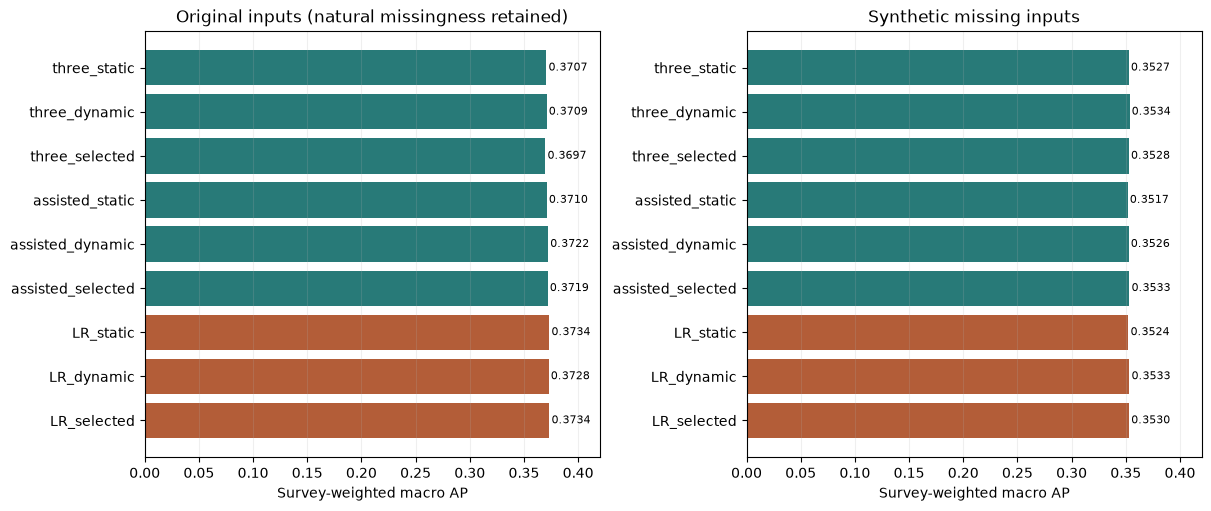

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
for ax, metric, title in zip(axes, ["clean_macro_AP", "missing_macro_AP"], ["Original inputs (natural missingness retained)", "Synthetic missing inputs"]):
    ax.barh(results.index, results[metric], color=["#287a78" if not x.startswith("LR") else "#b35d38" for x in results.index])
    ax.set_xlim(0, .42)
    ax.set_xlabel("Survey-weighted macro AP")
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=.2)
    for i,value in enumerate(results[metric]): ax.text(value+.002, i, f"{value:.4f}", va="center", fontsize=8)
plt.show()

## 강한 대조군 대비 차이

고정 OOF 예측의200회 PSU bootstrap 구간이다. 전체 모델 개발·학습·선택 불확실성이나 다중 비교 보정은 포함하지 않는다. 구간이0을 포함하면 이 결과만으로 우월성을 주장하지 않는다.

In [4]:
ci_rows=[]
for model in ["three_dynamic", "three_selected", "assisted_selected"]:
    for condition in ["clean", "missing20"]:
        for reference in ["LR_selected", "three_static", "LR_v13"]:
            low, high=DATA["latest"]["paired"][model][condition][reference]["ci95"]
            ci_rows.append(dict(model=model, condition=condition, reference=reference, lower=low, upper=high, includes_zero=low<=0<=high))
ci=pd.DataFrame(ci_rows)
display(ci.round(6))

,model,condition,reference,lower,upper,includes_zero
0,three_dynamic,clean,LR_selected,-0.006478,0.001246,True
1,three_dynamic,clean,three_static,-0.002500,0.002990,True
2,three_dynamic,clean,LR_v13,-0.003393,0.007302,True
3,three_dynamic,missing20,LR_selected,-0.003723,0.004126,True
4,three_dynamic,missing20,three_static,-0.002849,0.003802,True
5,three_dynamic,missing20,LR_v13,0.000870,0.011209,False
6,three_selected,clean,LR_selected,-0.008263,0.000782,True
7,three_selected,clean,three_static,-0.004187,0.002016,True
8,three_selected,clean,LR_v13,-0.004679,0.006425,True
9,three_selected,missing20,LR_selected,-0.004101,0.003657,True


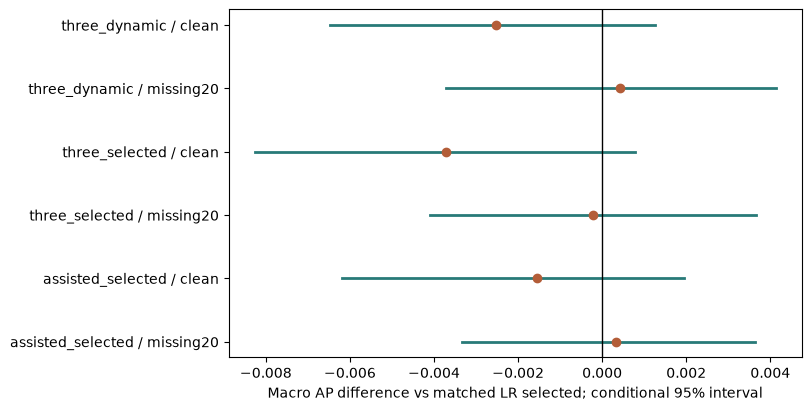

In [5]:
fig, ax=plt.subplots(figsize=(8,4), layout="constrained")
subset=ci[(ci.reference=="LR_selected")].reset_index(drop=True)
for i,row in subset.iterrows():
    metric="clean_macro_AP" if row.condition=="clean" else "missing_macro_AP"
    delta=results.loc[row.model,metric]-results.loc["LR_selected",metric]
    ax.plot([row.lower,row.upper],[i,i],color="#287a78",lw=2)
    ax.plot(delta,i,"o",color="#b35d38")
ax.axvline(0,color="black",lw=1)
ax.set_yticks(range(len(subset)), subset.model+" / "+subset.condition)
ax.set_xlabel("Macro AP difference vs matched LR selected; conditional 95% interval")
ax.invert_yaxis()
plt.show()

## 소견별 성능

같은 사람이 여러 양성 label을 가질 수 있다. glucose/bp/tg/low_hdl은 검사상 이상 소견이며 진단명이 아니다.

In [6]:
labels=["glucose", "bp", "tg", "low_hdl"]
per_label=pd.DataFrame({model: {labels[int(j)]: v["ap"] for j,v in DATA["latest"]["models"][model]["clean"]["per_label"].items()} for model in ["three_static", "three_dynamic", "three_selected", "LR_selected"]})
display(per_label.round(6))

,three_static,three_dynamic,three_selected,LR_selected
glucose,0.372833,0.373430,0.371937,0.377549
bp,0.284732,0.281387,0.281385,0.289238
tg,0.442863,0.444399,0.442807,0.445412
low_hdl,0.382175,0.384412,0.382806,0.381562


## fold별 선택과 네 상태의 학습 support

상태=입력 결측×소견별 expert logit 불일치. 불일치 기준은 학습 weighted75백분위, 국소·전역 logit의 혼합은 n/(n+tau). 이 기준은 설계 선택이며 의학적으로 입증된 경계가 아니다. 네 상태 모델은 fold2에서만 최종 선택됐다. support는 두 view에서 중복 제거한 사람 수이며 서로 다른 상태에 같은 사람이 나타날 수 있다.

In [7]:
selection=[]
for fold,part in enumerate(DATA["latest"]["selection"],1):
    for name in ["three_selected", "assisted_selected", "LR_selected"]:
        b=part["selected"][name]
        selection.append(dict(fold=fold,model=name,combiner=b["spec"]["kind"],config=b["spec"]["kwargs"],base_path=b["base_path"]))
display(pd.DataFrame(selection))
display(pd.DataFrame(DATA["latest"]["audit"][1]["states"]["three_selected"]))

,fold,model,combiner,config,base_path
0,1,three_selected,context_stack,"{'C': 0.01, 'mode': 'profile'}",inner_bag
1,1,assisted_selected,context_stack,"{'C': 0.01, 'mode': 'profile'}",inner_bag
2,1,LR_selected,context_stack,"{'C': 0.01, 'mode': 'profile'}",inner_bag
3,2,three_selected,state_stack,"{'C': 0.1, 'shrink_people': 500}",fullfit
4,2,assisted_selected,stack,{'C': 0.1},fullfit
5,2,LR_selected,context_stack,"{'C': 0.1, 'mode': 'quality'}",fullfit
6,3,three_selected,context_stack,"{'C': 0.01, 'mode': 'quality'}",fullfit
7,3,assisted_selected,context_stack,"{'C': 0.01, 'mode': 'quality'}",inner_bag
8,3,LR_selected,context_stack,"{'C': 0.01, 'mode': 'quality'}",inner_bag
9,4,three_selected,stack,{'C': 0.1},fullfit


,label,state,people,positive,negative,active,weight
0,0,complete_agree,1773,229,1544,True,0.780026
1,0,complete_disagree,570,63,507,True,0.532710
2,0,missing_agree,1965,242,1723,True,0.797160
3,0,missing_disagree,677,97,580,True,0.575191
4,1,complete_agree,1752,181,1571,True,0.777975
5,1,complete_disagree,591,54,537,True,0.541705
6,1,missing_agree,1946,185,1761,True,0.795585
7,1,missing_disagree,697,69,628,True,0.582289
8,2,complete_agree,1820,329,1491,True,0.784483
9,2,complete_disagree,523,88,435,True,0.511241


## 단계별 변화

원 Vortex의 정수 winding gradient 문제를 별도 smooth proxy로 보완했고, 물리/스파이킹 추가 특징의 중복·정규화를 조정했다. 여러 변경을 함께 적용한 단계별 비교로, 하나의 메커니즘의 인과 효과를 분리한 ablation은 아니다.

In [8]:
history=[]
for version,part in DATA["history"].items():
    for name,v in part["models"].items(): history.append(dict(version=version, model=name, clean_AP=v["clean"]["macro_ap"], missing_AP=v["missing20"]["macro_ap"]))
display(pd.DataFrame(history).round(6))

,version,model,clean_AP,missing_AP
0,v10,Vortex_original_code,0.317140,0.299433
1,v10,FREE_v01_physical_readout,0.359297,0.335911
2,v10,Portia_STDP_proposal,0.348674,0.322102
3,v12,LR_tuned,0.366339,0.344104
4,v12,Vortex_improved,0.353994,0.332927
5,v12,Physical_improved,0.355868,0.333554
6,v12,Portia_improved,0.355843,0.331544
7,v13,LR_tuned,0.369242,0.347058
8,v13,Vortex_alternating,0.361523,0.341783
9,v13,Physical_regularized,0.366322,0.345057


## 실제 실행과 검증

아래 속도는 따로 측정한 집계다. CPU1스레드, 가상 단건 입력,10회 워밍업/100회. 전처리·전체 전문가·결합·보정·출력 dict 포함, 로딩·JSON·HTTP 제외. 세 모델 결합의 base 실행 수는3개 또는9개로, 단일 패스나 LR보다 빠른 구현은 아니다.

In [9]:
display(pd.DataFrame(DATA["runtime"]["results"]).round(4))
print(DATA["runtime"]["scope"])
print("Local tests passed:",DATA["verification"]["local_tests_passed"])
print("OOF reload max difference:",max(x["max_abs_difference"] for x in DATA["verification"]["OOF_reload"]))
display(pd.DataFrame(DATA["verification"]["portable"]["results"]))

,fold,category,base_model_evaluations,p50_ms,p95_ms
0,1,three_selected,9,14.6934,18.2681
1,2,three_selected,3,5.3445,7.1591
2,1,LR_selected,3,1.3820,2.0534


Warm CPU one-thread, synthetic single-row input, input validation + preprocessing + all experts + combiner + calibration + output dict; excludes loading/JSON serialization/HTTP. 10 warmups,100 repeats; three separately timed methods.
Local tests passed: 106
OOF reload max difference: 0.0


,fold,category,rows_checked_per_view,max_abs_difference_clean,max_abs_difference_masked
0,1,three_selected,4068,0.0,0.0
1,2,three_selected,4068,0.0,0.0
2,1,LR_selected,4068,0.0,0.0


# 선행연구와 우리 모델의 차이

확인일: 2026-09-22. 원 논문·저자 공개본·공식 학회 페이지를 대상으로 확인했다. 체계적 문헌고찰이나 신규성에 대한 완전한 검색은 아니다.

**상태에 따라 전문가를 나누고 결합한다는 발상 자체는 기존 연구에 있다.** 우리 연구의 기여 후보는 복소 파동·물리 저장소·스파이킹 모델을 동일 정형 자료에서 유지하면서, 입력 결측과 소견별 예측 불일치에 따라 결합하고 그 효용을 대조군과 검증하는 구체적인 설계다. 현재 결과만으로 새로운 알고리즘의 최초 제안이나 LR 대비 우월성을 주장하지 않는다.

## 가장 가까운 결합·선택 연구

| 선행연구 | 기존에 제안한 부분 | 우리 구현과 겹치는 부분 | 구별되는 구현·검증 범위 |
|---|---|---|---|
| Jacobs et al., **Adaptive Mixtures of Local Experts**, Neural Computation 3:79–87, 1991. [원문](https://www.cs.toronto.edu/~hinton/absps/jjnh91.pdf) | 입력에 따라 gate가 전문가의 기여를 결정 | 입력 조건부 전문가 결합 | 우리는 같은 19개 정형 입력을 받는 서로 다른 메커니즘의 모델을 별도로 학습하고 OOF 출력에서 결합한다. 단일 end-to-end MoE의 최초 제안이 아니다. |
| Wolpert, **Stacked Generalization**, Neural Networks 5:241–259, 1992. [원문 공개본](https://cafri-labs.github.io/lab-manual/papers/wolpert1992.pdf), [DOI](https://doi.org/10.1016/S0893-6080(05)80023-1) | 학습 부분집합으로 나머지 자료를 예측한 값을 상위 학습기의 입력으로 이용 | inner OOF 예측으로 meta model 학습 | PSU를 분리한 3-fold OOF와 조사 가중치를 적용한다. OOF stacking 자체의 신규성을 주장하지 않는다. |
| Cruz et al., **META-DES**, Pattern Recognition 48:1925–1935, 2015. [저자 공개본](https://arxiv.org/abs/1810.01270), [DOI](https://doi.org/10.1016/j.patcog.2014.12.003) | 여러 meta-feature로 입력별 분류기 적합성을 추정하고 동적으로 선택 | 예측값·입력 상태에 따라 결합 방식 변화 | 우리는 이웃 기반 적합성 추정을 재현하지 않았다. 결측 여부와 label별 expert-logit 표준편차로 네 상태를 정의하고, 전역·국소 stacker를 축소 결합한다. arXiv 등록은 2018년이지만 저널 출판은 2015년이다. |
| Novosad, Carano & Krishnan, **A task-conditional mixture-of-experts model for missing modality segmentation**, MICCAI 2024. [공식 논문](https://papers.miccai.org/miccai-2024/paper/2509_paper.pdf), [DOI](https://doi.org/10.1007/978-3-031-72114-4_4) | MRI 모달리티의 가용성 코드를 softmax gate에 넣어 convolution experts를 결합하고 self-distillation 사용 | 결측 상태로 결합 조건을 정의 | 우리는 정형 자료의 개별 변수 결측을 다루고 모델 출력에서 결합한다. convolution MoE·self-distillation은 구현하지 않았다. **결측 상태별 결합에 선행연구가 없다는 주장을 직접 제한하는 연구다.** |
| Sun & Sheng, **QA-MoE**, IJCAI 2026, pp.6886–6894. [공식 페이지](https://www.ijcai.org/proceedings/2026/766), [원문](https://www.ijcai.org/proceedings/2026/0766.pdf) | 임상 다중모달 입력의 evidence 기반 품질 추정, 부분집합 선택, ternary routing을 분리 | 입력 품질에 따라 결합을 바꾸는 목적 | 우리는 Dirichlet evidence나 모달리티 부분집합 선택을 쓰지 않는다. 단순 expert disagreement는 보정된 epistemic uncertainty가 아니다. 모든 전문가를 계산한 후 결합하므로 sparse routing의 계산 절감도 주장하지 않는다. |

이 표는 **개념·구조 비교**다. META-DES, MICCAI 모델, QA-MoE를 동일 자료에서 재현해 성능을 이겼다는 실험은 없다. 논문마다 데이터·목표·지표가 달라 발표 점수를 우리 macro AP와 직접 순위 비교하지 않았다.

## 세 전문가의 메커니즘에 대한 선행연구

| 관련 원리와 원 논문 | 우리 모델에서 유지한 것 | 이번 구현의 범위 |
|---|---|---|
| 복소수·unitary 전파: Arjovsky, Shah & Bengio, **Unitary Evolution Recurrent Neural Networks**, ICML 2016. [공식 논문](https://proceedings.mlr.press/v48/arjovsky16.html) | Vortex의 복소 진폭·위상, Cayley 전파와 GP 비선형 변환 | 원 논문의 장기 시계열 RNN 재현이 아니다. 정적 입력에 유한 단계 파동을 적용하고, 별도 smooth phase proxy와 교대 readout 학습을 쓴다. 복소수/unitary라는 이유만으로 새로운 원리라고 주장하지 않는다. |
| 물리 저장소: Nakajima et al., **Information processing via physical soft body**, Scientific Reports 5:10487, 2015. [원 논문](https://www.nature.com/articles/srep10487) | 동역학 응답을 계산 특징으로 이용하는 관점 | 우리는 실제 연성체 장치를 사용하지 않는다. 기존 FREE v0.1 quartic 매질/BAOAB의 소프트웨어 시뮬레이션으로 구동·감쇠 특징을 만들고, 추가 특징만 정규화한다. 최신 FREE v0.2 전체 시스템의 평가도 아니다. |
| 조절 STDP·eligibility trace: Florian, **Reinforcement Learning Through Modulation of Spike-Timing-Dependent Synaptic Plasticity**, Neural Computation 19:1468–1502, 2007. [저자 원문](https://florian.io/papers/2007_Florian_Modulated_STDP.pdf) | Portia 후보의 LIF 발화, E/I 연결, 국소 가소성·조절 신호 | 우리의 조절 신호는 학습 자료의 label에서 온다. 원 논문의 reward 기반 RL, 실제 거미 커넥톰, 생물학적 검증을 재현했다는 뜻이 아니다. |

## 우리가 실제로 추가한 설계

`statewise_hybrid.py`의 소견 j에 대한 상태는 다음과 같다.

1. 입력 완전성: age·sex를 제외한 입력 중 하나라도 결측인지 판정한다. `clean` 평가에도 원자료의 자연 결측은 남아 있다.
2. 예측 불일치: 세 전문가의 j번째 logit 표준편차가 meta 학습 자료의 조사 가중 75백분위수를 초과하는지 판정한다.
3. 두 조건의 조합으로 `complete_agree`, `complete_disagree`, `missing_agree`, `missing_disagree`를 만든다. 정답 소견이나 혈액 수치로 상태를 정하지 않는다.
4. 전역 stacker와 상태별 stacker의 logit을 `alpha = n / (n + tau)`로 결합한다. `n`은 해당 상태의 **중복 제거된 사람 수**다. 같은 사람의 원래 입력과 누락 입력을 별도 사람으로 세지 않는다. 양성·음성이 각각 20명 미만이면 그 상태에서는 전역 모델을 쓴다.

75백분위수, 최소 양·음성 20명, shrinkage tau 후보 100/500, 입력군 구성은 **이번 연구의 설계 선택**이다. 위 논문이 이 숫자의 최적성이나 의학적 타당성을 입증한 것은 아니다. tau는 개발 검증 자료에서 선택했으며, 나머지 고정 기준의 민감도 분석은 하지 않았다.

별도로 입력 품질/프로필과 expert logit의 상호작용, softmax 혼합도 비교했다. 이들은 각각 `conditional_hybrid.py`의 `ContextualLogitStack`, `ContextualMixture`다. stacker 계수는 음수도 가능하므로 ‘전문가의 기여 비율’로 읽으면 안 된다. softmax 모델의 gate만 비음수·합계 1의 혼합 비율이다.

세 전문가의 출력층과 결합층에도 로지스틱 학습이 쓰인다. `three`는 **별도의 LR 전문가를 넣지 않았다**는 뜻이며, 모델 내부의 모든 선형·로지스틱 계산을 제거했다는 뜻은 아니다.

## 결과로 뒷받침되는 범위

- 동적 결합 후보군은 세 모델의 고정 결합 대비 macro AP가 원래 입력에서 0.3707→0.3709, 인공 누락에서 0.3527→0.3534였다. 차이의 조건부 95% 구간은 두 조건 모두 0을 포함한다.
- 같은 탐색 절차의 LR 대조군은 0.3734 / 0.3530이었다. 따라서 상태 결합의 확정적 효과나 LR 대비 우월성은 입증되지 않았다.
- 명시적인 네 상태 stacker는 세 모델의 최종 선택에서 5개 outer fold 중 **fold2 한 번** 선택됐다. 다른 fold는 연속 context 모델 또는 고정 결합을 선택했다. 전체 결과를 네 상태 모델 하나의 성능이라고 쓰면 안 된다.
- 이 자료는 여러 차례 개선에 재사용됐다. 고정 OOF 예측의 PSU bootstrap은 전체 개발·선택 과정의 불확실성을 보장하지 않는다.

현재 적절한 기술은 **“서로 다른 메커니즘을 유지한 정형 자료 전문가의 상태 조건부 결합과 대조 실험”**이다. 추가로 필요한 근거는 새로운 자료에서의 검증, 고정 결합 대비 안정된 효과, 상태 기준 민감도, 동일 용량·계산량 및 재학습 ablation이다. 이 항목들을 완료했다고 주장하지 않는다.


## 활용 결정

현재 LR 대조군을 기본 모델로 유지한다. 세 모델의 조건부 결합은 누락 강건성 연구 후보로 보존한다. 모델 구조의 차이는 존재하지만, 기존 MoE/stacking/동적 선택과 구별되는 학술적 효과를 입증하려면 새로운 자료, 고정 결합 대조, 동일 용량·계산량 대조와 재학습 ablation이 추가로 필요하다.

공개 가중치는 실제 단일 fold 예제다. 위 표는5fold OOF이므로 예제 체크포인트의 점수로 읽지 않는다. 원자료·개인별 예측은 이 노트북에 포함되지 않는다.